In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
consDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
consDF = consDF.drop(columns = ["credit_score"])
consDF = consDF.dropna()
acctDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
trxnDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")
catmap = pd.read_csv("/uss/hdsi-prismdata/q2-ucsd-cat-map.csv")
acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])
date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

trxnDF = trxnDF.merge(catmap, left_on='category', right_on="category_id", how='left').drop(columns=["category_x"], errors='ignore')
if 'category_y' in trxnDF.columns:
    trxnDF['category'] = trxnDF['category_y'] 
        
trxnDF = trxnDF.merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')

In [3]:
linked_accounts = (
    acctDF
    .groupby("prism_consumer_id")["prism_account_id"]
    .nunique()
)

eligible_linked = linked_accounts[linked_accounts >= 1].index

# Apply filter
consDF = consDF[consDF["prism_consumer_id"].isin(eligible_linked)]
acctDF = acctDF[acctDF["prism_consumer_id"].isin(eligible_linked)]
trxnDF = trxnDF[trxnDF["prism_consumer_id"].isin(eligible_linked)]

In [4]:
trxnDF["year_month"] = trxnDF["posted_date"].dt.to_period("M")

txn_months = (
    trxnDF
    .groupby("prism_consumer_id")["year_month"]
    .nunique()
)
eligible_history = txn_months[txn_months >= 3].index
consDF = consDF[consDF["prism_consumer_id"].isin(eligible_history)]
acctDF = acctDF[acctDF["prism_consumer_id"].isin(eligible_history)]
trxnDF = trxnDF[trxnDF["prism_consumer_id"].isin(eligible_history)]

In [5]:
import pandas as pd
import numpy as np
import pywt

def calculate_running_balance(t_df, a_df):
    t_df = t_df.copy()
    t_df['signed_amount'] = np.where(t_df['credit_or_debit'] == 'DEBIT', -t_df['amount'], t_df['amount'])
    sort_cols = ['prism_consumer_id', 'posted_date']
    if 'prism_transaction_id' in t_df.columns: sort_cols.append('prism_transaction_id')
    t_df = t_df.sort_values(sort_cols)
    t_df['raw_cumsum'] = t_df.groupby('prism_consumer_id')['signed_amount'].cumsum()
    snapshot = a_df.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
    snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})
    df_merged = t_df.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')
    anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
    df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')
    df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']
    out_cols = ['prism_consumer_id', 'posted_date', 'category_id', 'category', 'amount', 'signed_amount', 'credit_or_debit', 'running_balance', 'DQ_TARGET']
    return df_merged[[c for c in out_cols if c in df_merged.columns]]

def extract_consumer_habits(df):
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_name'], values='signed_amount').fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(index='prism_consumer_id', columns=['category', 'day_of_month'], values='signed_amount').fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]

    def get_wavelet_power(series):
        if len(series) < 14 or series.sum() == 0: return 0, 0
        vals = series.values - series.mean()
        cf = pywt.central_frequency('morl')
        if len(vals) >= 28:
            coef, _ = pywt.cwt(vals, [cf*7, cf*30], 'morl')
            return np.mean(np.abs(coef[0])**2), np.mean(np.abs(coef[1])**2)
        coef, _ = pywt.cwt(vals, [cf*7], 'morl')
        return np.mean(np.abs(coef[0])**2), 0

    cwt_results = []
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily = group.groupby('posted_date')['signed_amount'].sum()
        series = daily.reindex(pd.date_range(daily.index.min(), daily.index.max()), fill_value=0)
        w, m = get_wavelet_power(series)
        cwt_results.append({'prism_consumer_id': cons_id, 'category': cat, 'cwt_weekly_habit': w, 'cwt_monthly_habit': m})
    
    cwt_df = pd.DataFrame(cwt_results)
    if not cwt_df.empty:
        cwt_pivot_w = cwt_df.pivot(index='prism_consumer_id', columns='category', values='cwt_weekly_habit').fillna(0)
        cwt_pivot_w.columns = [f"cat_{c}_cwt_weekly" for c in cwt_pivot_w.columns]
        cwt_pivot_m = cwt_df.pivot(index='prism_consumer_id', columns='category', values='cwt_monthly_habit').fillna(0)
        cwt_pivot_m.columns = [f"cat_{c}_cwt_monthly" for c in cwt_pivot_m.columns]
    else:
        cwt_pivot_w, cwt_pivot_m = pd.DataFrame(), pd.DataFrame()

    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    return weekly_pivot.join(monthly_pivot, how='outer').join(cwt_pivot_w, how='outer').join(cwt_pivot_m, how='outer').join(target_map, how='outer')

def build_global_tx_features(df_tx):
    df = df_tx.copy()
    df['abs_amount'] = df['amount'].abs()
    cat_counts = df.groupby(['prism_consumer_id', 'category']).size()
    total_counts = df.groupby('prism_consumer_id').size()
    count_props = cat_counts.div(total_counts, level='prism_consumer_id').unstack(fill_value=0)
    count_props.columns = [f"prop_count_cat_{c}" for c in count_props.columns]
    return count_props

def build_account_features(acctDF):
    agg_bal = acctDF.groupby("prism_consumer_id", as_index=False).agg(avg_balance=("balance", "mean"), max_balance=("balance", "max"), min_balance=("balance", "min"), num_accounts=("balance", "count"))
    pivot_bal = acctDF.pivot_table(index="prism_consumer_id", columns="account_type", values="balance", aggfunc="sum", fill_value=0).reset_index()
    pivot_bal["checking_to_savings_ratio"] = pivot_bal.get("CHECKING", 0) / (pivot_bal.get("SAVINGS", 0) + 1)
    return agg_bal, pivot_bal, pd.DataFrame()

def build_income_features(history_train):
    INCOME_CATS = ["DEPOSIT", "PAYCHECK", "INVESTMENT_INCOME"]
    income_txn = history_train[(history_train["credit_or_debit"] == "CREDIT") & (history_train["category"].isin(INCOME_CATS))].copy()
    avg_inc = income_txn.groupby("prism_consumer_id")["amount"].mean().reset_index(name="avg_monthly_income")
    return (avg_inc,)

def build_balance_dynamics(history_train):
    df = history_train.sort_values(["prism_consumer_id", "posted_date"]).copy()
    df["daily_change"] = df.groupby("prism_consumer_id")["running_balance"].diff()
    dyn = df.groupby("prism_consumer_id", as_index=False).agg(mean_daily_change=("daily_change", "mean"), std_daily_change=("daily_change", "std"))
    return (dyn,)

def build_balance_magnitude(history_train):
    return history_train.groupby('prism_consumer_id')['running_balance'].quantile([0.25, 0.5, 0.75]).unstack().reset_index()

def build_quality_of_drawdown(history_subset):
    df = history_subset.copy()
    cutoff_dates = df.groupby('prism_consumer_id')['posted_date'].transform('max') - pd.Timedelta(days=30)
    recent_30d = df[df['posted_date'] >= cutoff_dates]
    
    total_outflows = recent_30d[recent_30d['credit_or_debit'] == 'DEBIT'].groupby('prism_consumer_id')['amount'].sum()
    wealth_cats = ['SELF_TRANSFER', 'EXTERNAL_TRANSFER', 'INVESTMENT']
    wealth_outflows = recent_30d[(recent_30d['credit_or_debit'] == 'DEBIT') & 
                                 (recent_30d['category'].isin(wealth_cats))].groupby('prism_consumer_id')['amount'].sum()
    stress_cats = ['OVERDRAFT', 'ACCOUNT_FEES', 'SMALL_DOLLAR_ADVANCE']
    stress_outflows = recent_30d[(recent_30d['credit_or_debit'] == 'DEBIT') & 
                                 (recent_30d['category'].isin(stress_cats))].groupby('prism_consumer_id')['amount'].sum()
    drawdown_df = pd.DataFrame({
        'wealth_transfer_ratio': wealth_outflows / (total_outflows + 1e-6),
        'stress_outflow_ratio': stress_outflows / (total_outflows + 1e-6)
    }).reset_index()
    return drawdown_df

def build_cash_utilization(history_subset):
    df = history_subset.copy()
    total_debits = df[df['credit_or_debit'] == 'DEBIT'].groupby('prism_consumer_id')['amount'].sum()
    cash_debits = df[(df['credit_or_debit'] == 'DEBIT') & 
                     (df['category'] == 'ATM_CASH')].groupby('prism_consumer_id')['amount'].sum()
    cash_df = pd.DataFrame({
        'cash_utilization_pct': cash_debits / (total_debits + 1e-6)
    }).reset_index()
    return cash_df

def build_BNPL_utilization(history_subset):
    df = history_subset.copy()
    total_debits = df[df['credit_or_debit'] == 'DEBIT'].groupby('prism_consumer_id')['amount'].sum()
    BNPL_debits = df[(df['credit_or_debit'] == 'DEBIT') & 
                     (df['category'] == 'BNPL')].groupby('prism_consumer_id')['amount'].sum()
    BNPL_df = pd.DataFrame({
        'BNPL_utilization_pct': BNPL_debits / (total_debits + 1e-6)
    }).reset_index()
    return BNPL_df

def build_spending_volatility_and_stress(history_subset):
    df = history_subset.copy()
    df['daily_abs_change'] = df.groupby('prism_consumer_id')['running_balance'].diff().abs()
    vola = df.groupby('prism_consumer_id')['daily_abs_change'].std().reset_index(name='spending_volatility')
    overdrafts = df[df['category'] == 'OVERDRAFT'].groupby('prism_consumer_id').size().reset_index(name='overdraft_count')
    total_debits = df[df['credit_or_debit'] == 'DEBIT'].groupby('prism_consumer_id').size().reset_index(name='total_debits')
    stress = pd.merge(overdrafts, total_debits, on='prism_consumer_id', how='right').fillna(0)
    stress['liquidity_stress_ratio'] = stress['overdraft_count'] / (stress['total_debits'] + 1e-6)
    final_feats = pd.merge(vola, stress[['prism_consumer_id', 'liquidity_stress_ratio']], on='prism_consumer_id', how='outer')
    return final_feats

def build_monthly_velocity(history_subset):
    df = history_subset.copy()
    df['transaction_month'] = df['posted_date'].dt.to_period('M')
    txn_freq = df.groupby(['prism_consumer_id', 'transaction_month']).size().reset_index(name='monthly_txn_count')
    avg_txn_freq = txn_freq.groupby('prism_consumer_id')['monthly_txn_count'].mean().reset_index(name='avg_txn_freq_per_month')
    return avg_txn_freq

def build_transaction_ratios(history_subset, acct_df):
    df = history_subset.copy()
    txn_count = df.groupby('prism_consumer_id').size().reset_index(name='total_transactions')
    lifespan = df.groupby('prism_consumer_id')['posted_date'].agg(lambda x: (x.max() - x.min()).days + 1).reset_index(name='days_observed')
    merged = txn_count.merge(lifespan, on='prism_consumer_id')
    merged['txns_per_day'] = merged['total_transactions'] / merged['days_observed']
    merged = merged.merge(acct_df[['prism_consumer_id', 'balance']], on='prism_consumer_id', how='left')
    merged['txn_rate_to_balance_ratio'] = (merged['txns_per_day'] / (merged['balance'] + 1e-6)).fillna(0)
    return merged[['prism_consumer_id', 'txn_rate_to_balance_ratio']]

# --- NOVEL AGENT DISCOVERED FEATURES ---

def build_nonlinear_ratio(history_subset, acct_df):
    df = history_subset.copy()
    df['balance_to_amount_ratio'] = (np.abs(df['running_balance']) / (np.abs(df['amount']) + 1e-6)).fillna(0)
    df['nonlinear_transformed_ratio'] = np.cos(np.tanh(df['balance_to_amount_ratio'] * 2) * np.pi).fillna(0)
    result_df = df.groupby('prism_consumer_id')['nonlinear_transformed_ratio'].mean().reset_index()
    return result_df[['prism_consumer_id', 'nonlinear_transformed_ratio']]

def build_stress_intensity(history_subset, acct_df):
    if history_subset.empty or acct_df.empty:
        return pd.DataFrame(columns=['prism_consumer_id', 'stress_intensity_asset_ratio'])
        
    df = history_subset.copy()
    a_df = acct_df.copy()
    df['prism_consumer_id'] = df['prism_consumer_id'].astype(str)
    a_df['prism_consumer_id'] = a_df['prism_consumer_id'].astype(str)
    
    stress_mask = df['running_balance'] <= 0
    stress_agg = df[stress_mask].groupby('prism_consumer_id')['signed_amount'].agg(mean_stress_spending='mean').reset_index()
    stress_agg['abs_stress'] = np.abs(stress_agg['mean_stress_spending'])
    
    asset_agg = a_df.groupby('prism_consumer_id')['balance'].agg(avg_asset_buffer='mean').reset_index()
    unique_consumers = df['prism_consumer_id'].unique()
    
    result = pd.merge(pd.DataFrame({'prism_consumer_id': unique_consumers}), stress_agg[['prism_consumer_id', 'abs_stress']], on='prism_consumer_id', how='left')
    result['abs_stress'] = result['abs_stress'].fillna(0.0)
    
    merged_df = pd.merge(result, asset_agg, on='prism_consumer_id', how='left')
    merged_df['avg_asset_buffer'] = merged_df['avg_asset_buffer'].fillna(1.0)
    merged_df['raw_intensity_ratio'] = merged_df['abs_stress'] / (merged_df['avg_asset_buffer'] + 1e-6)
    merged_df['stress_intensity_asset_ratio'] = np.tanh(merged_df['raw_intensity_ratio']).astype('float32')
    merged_df['stress_intensity_asset_ratio'] = merged_df['stress_intensity_asset_ratio'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    
    if merged_df['prism_consumer_id'].duplicated().any():
        merged_df = merged_df.drop_duplicates(subset=['prism_consumer_id'], keep='first')
    return merged_df[['prism_consumer_id', 'stress_intensity_asset_ratio']]

def build_state_switching_volatility(history_subset, acct_df):
    if history_subset.empty:
        return pd.DataFrame({'prism_consumer_id': [], 'novel_balance_state_switching_volatility': []})
        
    df = history_subset.copy()
    df['prism_consumer_id'] = df['prism_consumer_id'].astype(str)
    df = df.sort_values(['prism_consumer_id', 'posted_date']).reset_index(drop=True)
    
    df['state_negative'] = (df['running_balance'] <= 0).astype(int)
    df['prev_state'] = df.groupby('prism_consumer_id')['state_negative'].shift(1)
    df['is_transition'] = (df['state_negative'] != df['prev_state']).astype(int)
    
    transition_stats = df.groupby('prism_consumer_id').agg(num_transitions=('is_transition', 'sum'), total_transactions=('state_negative', 'count')).reset_index()
    transition_stats['switching_rate'] = transition_stats['num_transitions'] / (transition_stats['total_transactions'] + 1e-6)
    
    if not acct_df.empty:
        a_df = acct_df.copy()
        a_df['prism_consumer_id'] = a_df['prism_consumer_id'].astype(str)
        acct_agg = a_df.groupby('prism_consumer_id')['balance'].mean().reset_index()
        acct_agg.columns = ['prism_consumer_id', 'avg_account_balance']
        merged_stats = pd.merge(transition_stats, acct_agg, on='prism_consumer_id', how='left')
        merged_stats['avg_account_balance'] = merged_stats['avg_account_balance'].fillna(1.0)
    else:
        merged_stats = transition_stats.copy()
        merged_stats['avg_account_balance'] = 1.0
        
    merged_stats['wealth_normalized_switching'] = (merged_stats['switching_rate'] * 10.0) / (np.abs(merged_stats['avg_account_balance']) + 1e-6)
    merged_stats['novel_balance_state_switching_volatility'] = np.tanh(merged_stats['wealth_normalized_switching']).astype('float32')
    
    result_df = merged_stats[['prism_consumer_id', 'novel_balance_state_switching_volatility']].copy()
    result_df['novel_balance_state_switching_volatility'] = result_df['novel_balance_state_switching_volatility'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    
    if result_df['prism_consumer_id'].duplicated().any():
        result_df = result_df.drop_duplicates(subset=['prism_consumer_id'], keep='first')
    return result_df.reset_index(drop=True)

def build_volatility_regime_shift(history_subset, acct_df):
    if history_subset.empty:
        return pd.DataFrame(columns=['prism_consumer_id', 'recent_volatility_regime_shift_index'])
        
    df = history_subset.copy()
    df['prism_consumer_id'] = df['prism_consumer_id'].astype(str)
    df = df.sort_values(['prism_consumer_id', 'posted_date']).reset_index(drop=True)
    df['abs_balance_change'] = df.groupby('prism_consumer_id')['running_balance'].diff().fillna(0).abs()
    
    max_dates = df.groupby('prism_consumer_id')['posted_date'].max().reset_index()
    df = df.merge(max_dates, on='prism_consumer_id', how='left', suffixes=('', '_max'))
    cutoff_date = df['posted_date_max'] - pd.Timedelta(days=90)
    df['is_recent'] = df['posted_date'] >= cutoff_date
    
    recent_vol = df[df['is_recent']].groupby('prism_consumer_id')['abs_balance_change'].mean().reset_index(name='recent_mean_vol')
    hist_vol = df[~df['is_recent']].groupby('prism_consumer_id')['abs_balance_change'].mean().reset_index(name='historical_mean_vol')
    merged_stats = pd.merge(recent_vol, hist_vol, on='prism_consumer_id', how='outer').fillna(0)
    merged_stats['volatility_ratio_raw'] = merged_stats['recent_mean_vol'] / (merged_stats['historical_mean_vol'] + 1e-6)
    
    if not acct_df.empty:
        a_df = acct_df.copy()
        a_df['prism_consumer_id'] = a_df['prism_consumer_id'].astype(str)
        acct_agg = a_df.groupby('prism_consumer_id')['balance'].mean().reset_index(name='avg_account_balance')
        merged_stats = pd.merge(merged_stats, acct_agg, on='prism_consumer_id', how='left')
        merged_stats['avg_account_balance'] = merged_stats['avg_account_balance'].fillna(1.0)
    else:
        merged_stats['avg_account_balance'] = 1.0
        
    merged_stats['wealth_adjusted_score'] = merged_stats['volatility_ratio_raw'] / (np.abs(merged_stats['avg_account_balance']) + 1e-6)
    merged_stats['recent_volatility_regime_shift_index'] = np.tanh(merged_stats['wealth_adjusted_score']).astype('float32')
    
    result_df = merged_stats[['prism_consumer_id', 'recent_volatility_regime_shift_index']].copy()
    result_df['recent_volatility_regime_shift_index'] = result_df['recent_volatility_regime_shift_index'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    
    if result_df['prism_consumer_id'].duplicated().any():
        result_df = result_df.drop_duplicates(subset=['prism_consumer_id'], keep='first')
    return result_df.reset_index(drop=True)


def extract_ALL_features(history_subset, acct_df):
    print("Extracting full habit matrix...")
    base_features = extract_consumer_habits(history_subset)
    agg_bal, pivot_bal, _ = build_account_features(acct_df) 
    income_feats = build_income_features(history_subset)
    balance_feats = build_balance_dynamics(history_subset)
    magnitude_feats = build_balance_magnitude(history_subset)
    drawdown = build_quality_of_drawdown(history_subset)
    cash = build_cash_utilization(history_subset)
    bnpl = build_BNPL_utilization(history_subset)
    global_tx_feats = build_global_tx_features(history_subset)
    volatility_feats = build_spending_volatility_and_stress(history_subset)
    velocity_feats = build_monthly_velocity(history_subset)
    ratio_feats = build_transaction_ratios(history_subset, acct_df)
    
    # AI Discoveries
    ai_nonlinear = build_nonlinear_ratio(history_subset, acct_df)
    ai_stress = build_stress_intensity(history_subset, acct_df)
    ai_state_switch = build_state_switching_volatility(history_subset, acct_df)
    ai_regime_shift = build_volatility_regime_shift(history_subset, acct_df)
    
    features_df = base_features.copy()
    
    all_new_dfs = (
        agg_bal, pivot_bal, *income_feats, *balance_feats, 
        magnitude_feats, drawdown, cash, bnpl, global_tx_feats,
        volatility_feats, velocity_feats, ratio_feats,
        ai_nonlinear, ai_stress, ai_state_switch, ai_regime_shift
    ) 
    
    for df in all_new_dfs:
        if 'prism_consumer_id' in df.columns:
            # Ensure type alignment for smooth indexing and joins
            df['prism_consumer_id'] = df['prism_consumer_id'].astype(str)
            df = df.set_index('prism_consumer_id')
        features_df = features_df.join(df, how='left')
        
    features_df.columns = features_df.columns.astype(str)
    return features_df.reset_index()

In [7]:
def evaluate_and_plot(y_holdout, final_test_probs, best_threshold):
    final_full_auc = roc_auc_score(y_holdout, final_test_probs)
    print(f"\n--- FINAL ENSEMBLE SUMMARY ---")
    print(f"Full Test ROC AUC: {final_full_auc:.4f}")

    roc_test_preds = (final_test_probs >= best_threshold).astype(int)

    print(f"\nOptimal ROC Threshold (from training): {best_threshold:.4f}\n")
    print(classification_report(y_holdout, roc_test_preds))

    plt.figure(figsize=(10, 6))
    plt.hist(final_test_probs[y_holdout == 0], bins=50, alpha=0.6, label='Actual Good (0)', color='green', density=True)
    plt.hist(final_test_probs[y_holdout == 1], bins=50, alpha=0.6, label='Actual Bad (1)', color='red', density=True)
    plt.axvline(best_threshold, color='black', linestyle='dashed', label=f'Threshold ({best_threshold:.3f})')
    plt.title('Test Set Predicted Probabilities')
    plt.legend()

In [8]:
history_all = calculate_running_balance(trxnDF, acctDF)
master_features_df = extract_ALL_features(history_all, acctDF)
    
master_features_df = master_features_df.dropna(subset=['DQ_TARGET'])
master_features_df = master_features_df.groupby('prism_consumer_id').max().reset_index()
total_consumers = len(master_features_df)


Extracting full habit matrix...


NameError: name 'train_test_split' is not defined

Final feature space size: 1913 columns.
Initializing Pilot Model & Hard Negative Mining...
Training 20-Model Balanced Ensemble...

--- FINAL ENSEMBLE SUMMARY ---
Full Test ROC AUC: 0.8150

Optimal ROC Threshold (from training): 0.5000

              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90      1704
         1.0       0.28      0.61      0.38       160

    accuracy                           0.83      1864
   macro avg       0.62      0.73      0.64      1864
weighted avg       0.90      0.83      0.86      1864



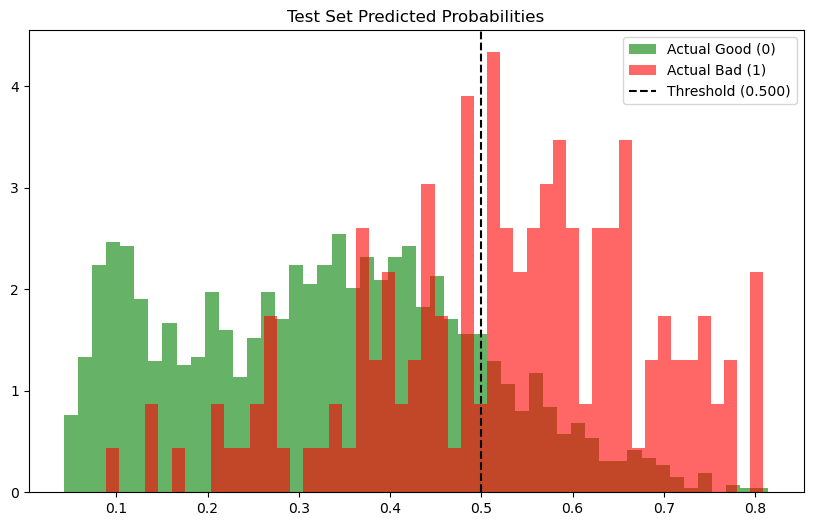

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
train_df, test_df = train_test_split(
    master_features_df, test_size=0.2,
    stratify=master_features_df['DQ_TARGET'],
    random_state= 111
)
    
X_train_full = train_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
X_test_full = test_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')

variances = X_train_full.var()
zero_var_cols = variances[variances == 0].index
    
exact_duplicates = [
    'std_daily_change', 
    'prop_count_cat_OVERDRAFT',
    '0.25'
]
    
monthly_cwt_cols = [col for col in X_train_full.columns if '_cwt_monthly' in col]
    
to_drop = list(zero_var_cols) + exact_duplicates + monthly_cwt_cols
    
train_df_pruned = train_df.drop(columns=[c for c in to_drop if c in train_df.columns])
test_df_pruned = test_df.drop(columns=[c for c in to_drop if c in test_df.columns])

print(f"Final feature space size: {train_df_pruned.shape[1]} columns.")
y_holdout = test_df_pruned['DQ_TARGET']

best_threshold, final_test_probs = train_easy_ensemble(
    train_df_pruned, test_df_pruned, num_iterations=20
)
evaluate_and_plot(y_holdout, final_test_probs, best_threshold)

In [6]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

def train_easy_ensemble_lgbm(train_df, test_df, num_iterations=20):
    print("Initializing Pilot Model & Hard Negative Mining...")
    
    # --- 0. Separate features, target, and identifiers ---
    X_train_full = train_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
    y_train_full = train_df['DQ_TARGET'].astype(int)
    
    X_test_full = test_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
    
    # --- 1. PILOT MODEL (for KNN hard negative mining) ---
    pilot_model = lgb.LGBMClassifier(n_estimators=100, max_depth=3, n_jobs=-1, verbose=-1)
    cv_preds = cross_val_predict(pilot_model, X_train_full, y_train_full, cv=5, method='predict_proba')[:, 1]
    
    # --- 2. DYNAMIC THRESHOLDING ---
    fpr, tpr, thresholds = roc_curve(y_train_full, cv_preds)
    best_threshold = thresholds[np.argmax(tpr - fpr)]
    
    
    # Hard negatives get 3x weight
    sample_weights = np.where((y_train_full == 0) & (cv_preds > best_threshold), 3.0, 1.0)
    
    # --- 4. ENSEMBLE TRAINING ---
    print(f"Training {num_iterations}-Model Balanced Ensemble with LightGBM...")
    ensemble_test_probs = np.zeros((len(X_test_full), num_iterations))
    
    majority_ids = train_df[train_df['DQ_TARGET'] == 0]['prism_consumer_id'].values
    minority_ids = train_df[train_df['DQ_TARGET'] == 1]['prism_consumer_id'].values
    minority_count = len(minority_ids)
    
    for i in range(num_iterations):
        # Balanced subsampling of majority class
        sampled_maj = np.random.choice(majority_ids, size=minority_count, replace=False)
        under_ids = np.concatenate([sampled_maj, minority_ids])
        
        mask = train_df['prism_consumer_id'].isin(under_ids)
        X_sub = X_train_full[mask]
        y_sub = y_train_full[mask]
        w_sub = sample_weights[mask]
        
        # Train LightGBM model
        #lgb_model = lgb.LGBMClassifier(
           # n_estimators=150,
            #learning_rate=0.05,
            #max_depth=3,
            #n_jobs=-1,
            #verbose=-1
        #)
        lgb_model = lgb.LGBMClassifier(
            n_estimators=300,           # more boosting rounds for better performance
            learning_rate=0.03,         # slightly smaller learning rate
            max_depth=5,                # deeper trees
            num_leaves=40,              # more leaves per tree
            min_child_samples=20,       # avoid overfitting small leaves
            subsample=0.8,              # row subsampling
            colsample_bytree=0.8,       # feature subsampling
            reg_alpha=0.1,              # L1 regularization
            reg_lambda=0.2,             # L2 regularization
            n_jobs=-1,
            verbose=-1
        )
        lgb_model.fit(X_sub, y_sub, sample_weight=w_sub)
        
        # Store predictions for ensemble
        ensemble_test_probs[:, i] = lgb_model.predict_proba(X_test_full)[:, 1]
    
    # --- 5. Average ensemble predictions ---
    final_test_probs = ensemble_test_probs.mean(axis=1)
    
    # Return default threshold and probabilities
    return 0.5, final_test_probs, lgb_model

In [7]:
best_threshold, final_test_probs, lgb_model = train_easy_ensemble_lgbm(
    train_df_pruned, test_df_pruned, num_iterations=20
)
evaluate_and_plot(y_holdout, final_test_probs, best_threshold)

NameError: name 'train_df_pruned' is not defined

In [9]:
from sklearn.model_selection import train_test_split
history_all = calculate_running_balance(trxnDF, acctDF)
master_features_df = extract_ALL_features(history_all, acctDF)

master_features_df = master_features_df.dropna(subset=['DQ_TARGET'])
master_features_df = master_features_df.groupby('prism_consumer_id').max().reset_index()
total_consumers = len(master_features_df)

train_df, test_df = train_test_split(
    master_features_df, test_size=0.2,
    stratify=master_features_df['DQ_TARGET'],
    random_state= 111
)

X_train_full = train_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
X_test_full = test_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')

variances = X_train_full.var()
zero_var_cols = variances[variances == 0].index

exact_duplicates = [
    'std_daily_change', 
    'prop_count_cat_OVERDRAFT',
    '0.25'
]

monthly_cwt_cols = [col for col in X_train_full.columns if '_cwt_monthly' in col]

to_drop = list(zero_var_cols) + exact_duplicates + monthly_cwt_cols

train_df_pruned = train_df.drop(columns=[c for c in to_drop if c in train_df.columns])
test_df_pruned = test_df.drop(columns=[c for c in to_drop if c in test_df.columns])

print(f"Final feature space size: {train_df_pruned.shape[1]} columns.")
y_holdout = test_df_pruned['DQ_TARGET']

Extracting full habit matrix...
Final feature space size: 1916 columns.


In [10]:
X_train_full = train_df_pruned.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train_full = train_df_pruned['DQ_TARGET'].astype(int)
    
X_test_full = test_df_pruned.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
    
# --- 1. PILOT MODEL (for KNN hard negative mining) ---
pilot_model = lgb.LGBMClassifier(n_estimators=100, max_depth=3, n_jobs=-1, verbose=-1)
cv_preds = cross_val_predict(pilot_model, X_train_full, y_train_full, cv=5, method='predict_proba')[:, 1]
    
# --- 2. DYNAMIC THRESHOLDING ---
fpr, tpr, thresholds = roc_curve(y_train_full, cv_preds)
best_threshold = thresholds[np.argmax(tpr - fpr)]
    
# Hard negatives get 3x weight
sample_weights = np.where((y_train_full == 0) & (cv_preds > best_threshold), 3.0, 1.0)

# --- 4. ENSEMBLE TRAINING ---
print(f"Training {20}-Model Balanced Ensemble with LightGBM...")
ensemble_test_probs = np.zeros((len(X_test_full), 20))

majority_ids = train_df[train_df['DQ_TARGET'] == 0]['prism_consumer_id'].values
minority_ids = train_df[train_df['DQ_TARGET'] == 1]['prism_consumer_id'].values
minority_count = len(minority_ids)

for i in range(20):
    # Balanced subsampling of majority class
    sampled_maj = np.random.choice(majority_ids, size=minority_count, replace=False)
    under_ids = np.concatenate([sampled_maj, minority_ids])
    
    mask = train_df['prism_consumer_id'].isin(under_ids)
    X_sub = X_train_full[mask]
    y_sub = y_train_full[mask]
    w_sub = sample_weights[mask]
    
    # Train LightGBM model
    #lgb_model = lgb.LGBMClassifier(
       # n_estimators=150,
        #learning_rate=0.05,
        #max_depth=3,
        #n_jobs=-1,
        #verbose=-1
    #)
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,           # more boosting rounds for better performance
        learning_rate=0.03,         # slightly smaller learning rate
        max_depth=5,                # deeper trees
        num_leaves=40,              # more leaves per tree
        min_child_samples=20,       # avoid overfitting small leaves
        subsample=0.8,              # row subsampling
        colsample_bytree=0.8,       # feature subsampling
        reg_alpha=0.1,              # L1 regularization
        reg_lambda=0.2,             # L2 regularization
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_sub, y_sub, sample_weight=w_sub)
    
    # Store predictions for ensemble
    ensemble_test_probs[:, i] = lgb_model.predict_proba(X_test_full)[:, 1]

# --- 5. Average ensemble predictions ---
final_test_probs = ensemble_test_probs.mean(axis=1)

Training 20-Model Balanced Ensemble with LightGBM...


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report
def evaluate_and_plot(y_holdout, final_test_probs, best_threshold):
    final_full_auc = roc_auc_score(y_holdout, final_test_probs)
    print(f"\n--- FINAL ENSEMBLE SUMMARY ---")
    print(f"Full Test ROC AUC: {final_full_auc:.4f}")

    roc_test_preds = (final_test_probs >= best_threshold).astype(int)

    print(f"\nOptimal ROC Threshold (from training): {best_threshold:.4f}\n")
    print(classification_report(y_holdout, roc_test_preds))

    plt.figure(figsize=(10, 6))
    plt.hist(final_test_probs[y_holdout == 0], bins=50, alpha=0.6, label='Actual Good (0)', color='green', density=True)
    plt.hist(final_test_probs[y_holdout == 1], bins=50, alpha=0.6, label='Actual Bad (1)', color='red', density=True)
    plt.axvline(best_threshold, color='black', linestyle='dashed', label=f'Threshold ({best_threshold:.3f})')
    plt.title('Test Set Predicted Probabilities')
    plt.legend()


--- FINAL ENSEMBLE SUMMARY ---
Full Test ROC AUC: 0.8247

Optimal ROC Threshold (from training): 0.0760

              precision    recall  f1-score   support

         0.0       1.00      0.17      0.29      1704
         1.0       0.10      0.99      0.18       160

    accuracy                           0.24      1864
   macro avg       0.55      0.58      0.24      1864
weighted avg       0.92      0.24      0.28      1864



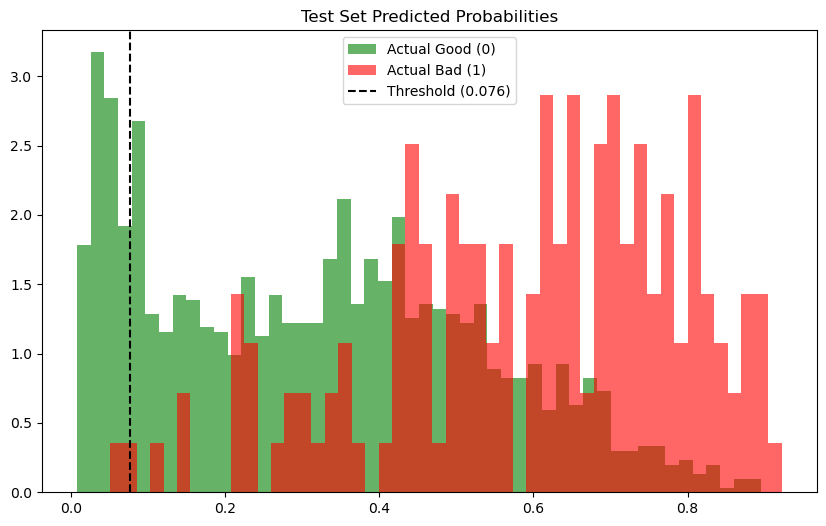

In [15]:
evaluate_and_plot(y_holdout, final_test_probs, best_threshold)

In [27]:
# --- TRAIN / TEST SPLIT ---
import time
pipeline_start_time = time.time()
X_train_full = train_df_pruned.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
y_train_full = train_df_pruned['DQ_TARGET'].astype(int)

X_test_full = test_df_pruned.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')

# --- 1. PILOT MODEL (for hard negative mining) ---
pilot_model = lgb.LGBMClassifier(n_estimators=100, max_depth=3, n_jobs=-1, verbose=-1)
cv_preds = cross_val_predict(pilot_model, X_train_full, y_train_full, cv=5, method='predict_proba')[:, 1]

# --- 2. DYNAMIC THRESHOLD ---
fpr, tpr, thresholds = roc_curve(y_train_full, cv_preds)
best_threshold = thresholds[np.argmax(tpr - fpr)]

# Hard negatives get 3x weight
sample_weights = np.where((y_train_full == 0) & (cv_preds > best_threshold), 3.0, 1.0)

# --- 3. ENSEMBLE TRAINING ---
N_MODELS = 20

print(f"Training {N_MODELS}-Model Balanced Ensemble with LightGBM...")

ensemble_test_probs = np.zeros((len(X_test_full), N_MODELS))
ensemble_train_probs = np.zeros((len(X_train_full), N_MODELS))

majority_ids = train_df[train_df['DQ_TARGET'] == 0]['prism_consumer_id'].values
minority_ids = train_df[train_df['DQ_TARGET'] == 1]['prism_consumer_id'].values
minority_count = len(minority_ids)

for i in range(N_MODELS):

    # --- Balanced subsampling ---
    sampled_maj = np.random.choice(majority_ids, size=minority_count, replace=False)
    under_ids = np.concatenate([sampled_maj, minority_ids])

    mask = train_df['prism_consumer_id'].isin(under_ids)

    X_sub = X_train_full[mask]
    y_sub = y_train_full[mask]
    w_sub = sample_weights[mask]

    # --- LightGBM model ---
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=40,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.2,
        n_jobs=-1,
        verbose=-1
    )

    lgb_model.fit(X_sub, y_sub, sample_weight=w_sub)

    # --- Store predictions ---
    ensemble_test_probs[:, i] = lgb_model.predict_proba(X_test_full)[:, 1]
    ensemble_train_probs[:, i] = lgb_model.predict_proba(X_train_full)[:, 1]

# --- 4. FINAL ENSEMBLE PREDICTIONS ---
final_test_probs = ensemble_test_probs.mean(axis=1)
final_train_probs = ensemble_train_probs.mean(axis=1)

pipeline_end_time = time.time()
total_time_seconds = pipeline_end_time - pipeline_start_time
total_time_minutes = total_time_seconds / 60
time_per_consumer = total_time_seconds / total_consumers

print("\n==================================================")
print("⏱️  PIPELINE LATENCY REPORT")
print("==================================================")
print(f"Total Labeled Consumers   : {total_consumers:,}")
print(f"Total Pipeline Time       : {total_time_minutes:.2f} minutes ({total_time_seconds:.1f} seconds)")
print(f"Average Time per Consumer : {time_per_consumer:.4f} seconds")
print("==================================================\n")

Training 20-Model Balanced Ensemble with LightGBM...

⏱️  PIPELINE LATENCY REPORT
Total Labeled Consumers   : 9,319
Total Pipeline Time       : 0.71 minutes (42.6 seconds)
Average Time per Consumer : 0.0046 seconds




--- FINAL ENSEMBLE SUMMARY ---
Full Test ROC AUC: 0.8261

Optimal ROC Threshold (from training): 0.0760

              precision    recall  f1-score   support

         0.0       0.99      0.18      0.31      1704
         1.0       0.10      0.99      0.18       160

    accuracy                           0.25      1864
   macro avg       0.55      0.59      0.25      1864
weighted avg       0.92      0.25      0.30      1864



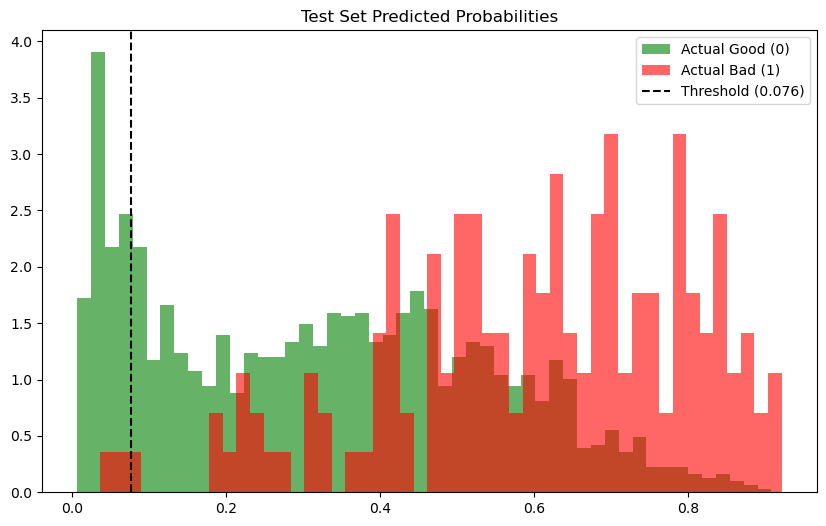

In [28]:
evaluate_and_plot(y_holdout, final_test_probs, best_threshold)


--- FINAL ENSEMBLE SUMMARY ---
Full Test ROC AUC: 0.9930

Optimal ROC Threshold (from training): 0.0760

              precision    recall  f1-score   support

           0       1.00      0.18      0.30      6816
           1       0.10      1.00      0.19       639

    accuracy                           0.25      7455
   macro avg       0.55      0.59      0.25      7455
weighted avg       0.92      0.25      0.29      7455



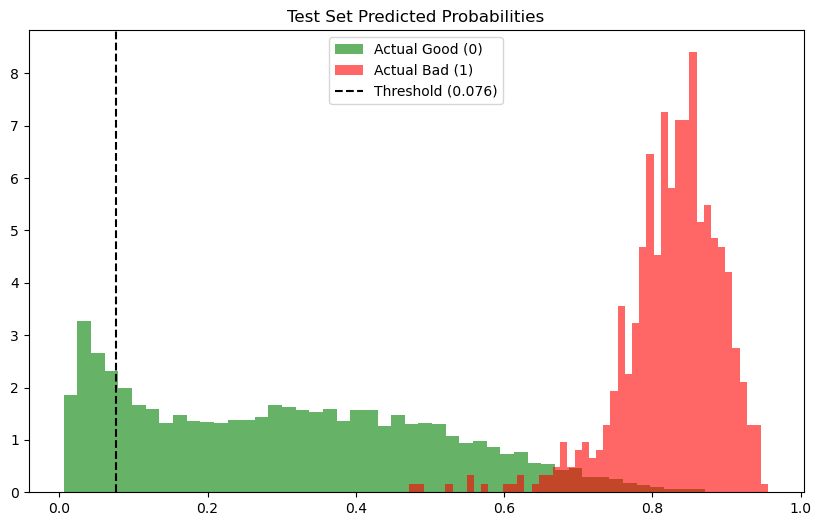

In [29]:
evaluate_and_plot(y_train_full, final_train_probs, best_threshold)

/home/chc099/.local/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


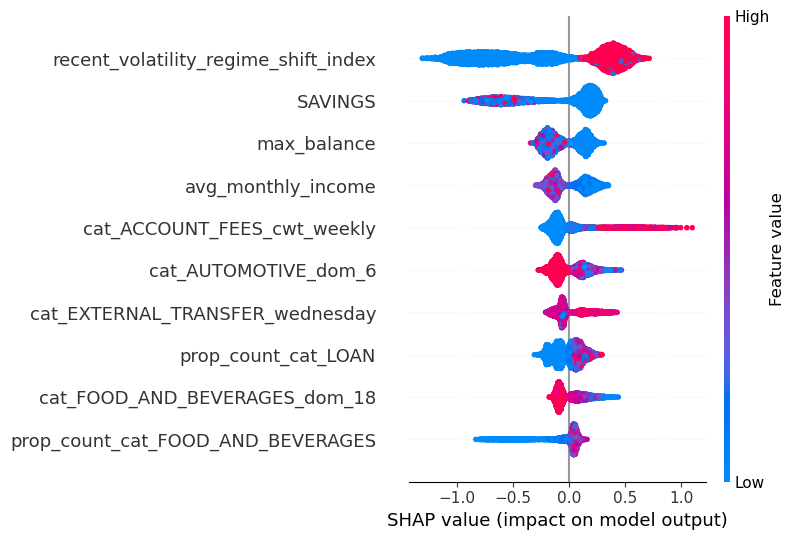

In [30]:
import shap
import matplotlib.pyplot as plt


X_train_full = train_df_pruned.drop(
    columns=['DQ_TARGET','prism_consumer_id','posted_date'], 
    errors='ignore'
)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_train_full)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values,
    X_train_full,
    max_display=10
)

In [34]:
consumer_idx = final_test_probs.argmax()
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_full)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

import pandas as pd

consumer_shap = shap_values[consumer_idx]
consumer_features = X_test_full.iloc[consumer_idx]

feature_importance = pd.DataFrame({
    "feature": X_test_full.columns,
    "feature_value": consumer_features.values,
    "shap_value": consumer_shap
})

# Sort by strongest positive impact
top10 = feature_importance.sort_values("shap_value", ascending=False).head(10)

print(top10)

                                   feature  feature_value  shap_value
1780           cat_ACCOUNT_FEES_cwt_weekly      42.172613    0.702047
1913  recent_volatility_regime_shift_index       1.000000    0.571999
109        cat_EXTERNAL_TRANSFER_wednesday      55.926000    0.219792
1850                               SAVINGS      -5.840000    0.185024
1852                    avg_monthly_income     560.009333    0.170485
1827                           avg_balance    -244.035000    0.164150
1828                           max_balance      -5.840000    0.141521
867          cat_FOOD_AND_BEVERAGES_dom_18     -24.590000    0.108212
1836                              CHECKING    -482.230000    0.106881
236                    cat_PAYCHECK_friday       0.000000    0.096233


/home/chc099/.local/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


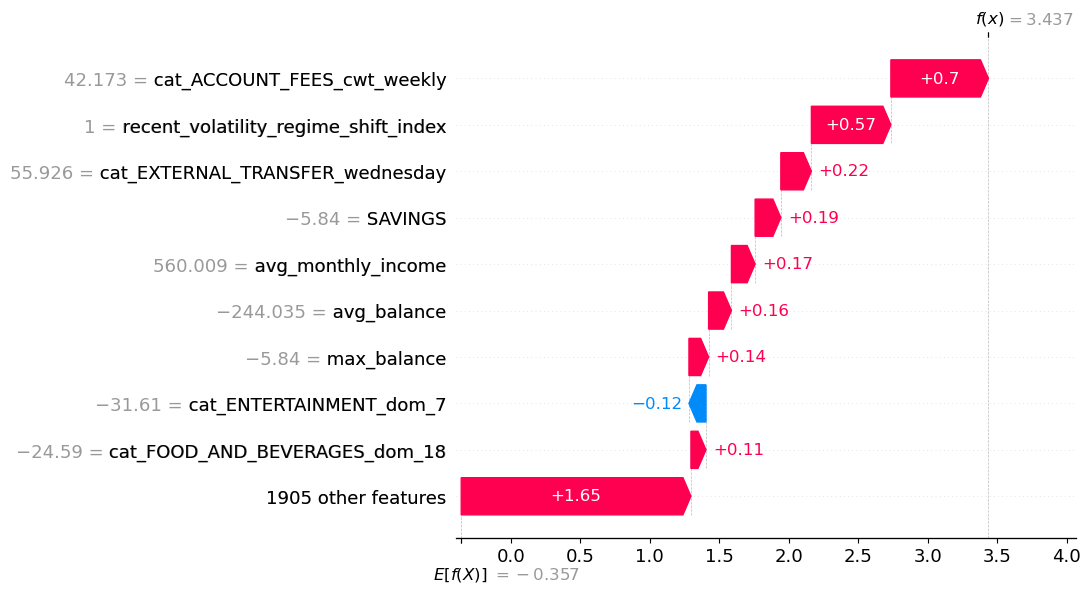

In [36]:
shap.plots.waterfall(
    shap.Explanation(
        values=consumer_shap,
        base_values=explainer.expected_value,
        data=consumer_features,
        feature_names=X_test_full.columns
    ),
    max_display=10
)